### Importing necessary libraries

In [3]:
from ucimlrepo import fetch_ucirepo 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,precision_score,recall_score,r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
# fetch dataset 
df = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = df.data.features 
y = df.data.targets 

### EDA & Data Preprocessing

In [6]:
## On X

print(X.head())

print(X.info())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   r

In [4]:
# On y
print(y.head())

print(y.info())

print(y.isnull().sum())

y['num'] = y['num'].apply(lambda x: 0 if x == 0 else 1)    ## REplacing 2 and 3 with 1 

print(y['num'].value_counts())
    

   num
0    0
1    2
2    1
3    0
4    0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   num     303 non-null    int64
dtypes: int64(1)
memory usage: 2.5 KB
None
num    0
dtype: int64
num
0    164
1    139
Name: count, dtype: int64


/var/folders/lv/fyd3l3n53b39fgvsn7t7bhnr0000gn/T/ipykernel_75007/2049052073.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['num'] = y['num'].apply(lambda x: 0 if x == 0 else 1)    ## REplacing 2 and 3 with 1


In [5]:
## Fill
X_clean = X.fillna(X.median(numeric_only=True))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)


## LOGISTIC REGRESSION MODEL

In [6]:
model=LogisticRegression()
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=5)
model.fit(X_train,y_train)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [7]:
y_pred=model.predict(X_test)

In [8]:
print("Accuracy score :",accuracy_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))
print("Confusion matrix: ",confusion_matrix(y_test,y_pred))
print("Precision score :",precision_score(y_test,y_pred))
print("Recall Score :",recall_score(y_test,y_pred))

Accuracy score : 0.8688524590163934
F1 Score : 0.8181818181818182
Confusion matrix:  [[35  3]
 [ 5 18]]
Precision score : 0.8571428571428571
Recall Score : 0.782608695652174


## RANDOM FOREST CLASSIFIER

In [9]:
model2= RandomForestClassifier()
model2.fit(X_train,y_train)
y_pred2=model2.predict(X_test)
print("Accuracy score :",accuracy_score(y_test,y_pred2))
print("F1 Score :",f1_score(y_test,y_pred2))
print("Comfusion matrix: ",confusion_matrix(y_test,y_pred2))
print("Precision score :",precision_score(y_test,y_pred2))
print("Recall Score :",recall_score(y_test,y_pred2))

Accuracy score : 0.8524590163934426
F1 Score : 0.8
Comfusion matrix:  [[34  4]
 [ 5 18]]
Precision score : 0.8181818181818182
Recall Score : 0.782608695652174


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


### Conclusion

# Cholesterol Level Prediction

Feature coefficients (influence on cholesterol):
sex        -10.820199
thalach      8.830844
restecg      8.423966
age          7.041504
trestbps     4.507409
exang        3.339808
thal         2.929877
cp           2.913720
fbs         -2.701676
slope       -1.198261
num          0.886770
ca           0.823302
oldpeak     -0.045466
dtype: float64


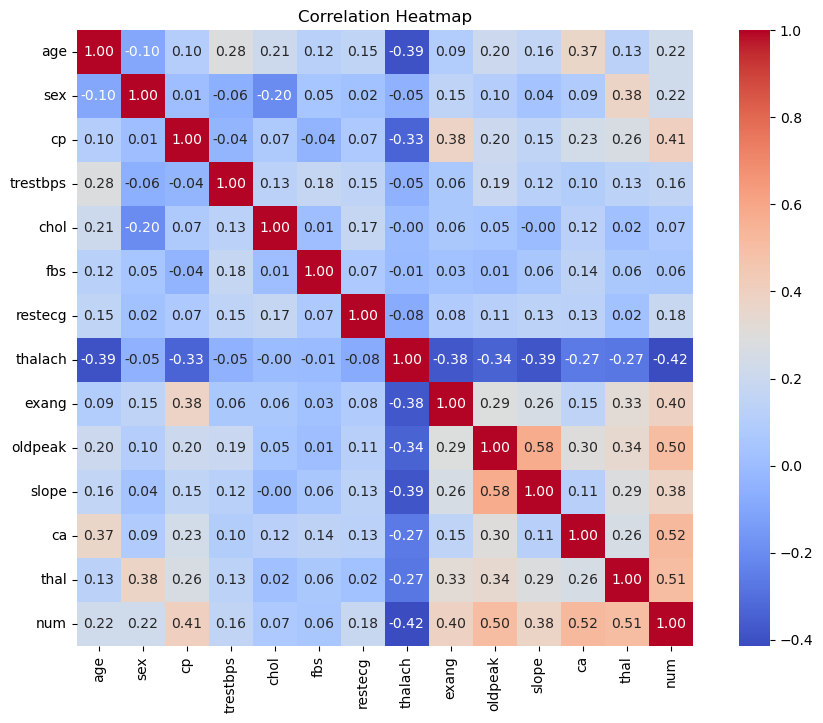


 Most correlated with cholesterol:
age         0.208950
sex        -0.199915
restecg     0.171043
trestbps    0.130120
ca          0.123726
Name: chol, dtype: float64


In [16]:
heart_data = fetch_ucirepo(id=45)
df = pd.concat([heart_data.data.features, heart_data.data.targets], axis=1)

df = df.fillna(df.median(numeric_only=True))

X = df.drop(columns='chol')
y = df['chol']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=5)

model = LinearRegression()
model.fit(X_train, y_train)

coefficients = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)

print("Feature coefficients (influence on cholesterol):")
print(coefficients)

y_pred = model.predict(X_test)

df_corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()

chol_corr = df_corr['chol'].drop('chol').sort_values(key=abs, ascending=False)

print("\n Most correlated with cholesterol:")
print(chol_corr.head(5))

## Principal Component Analysis

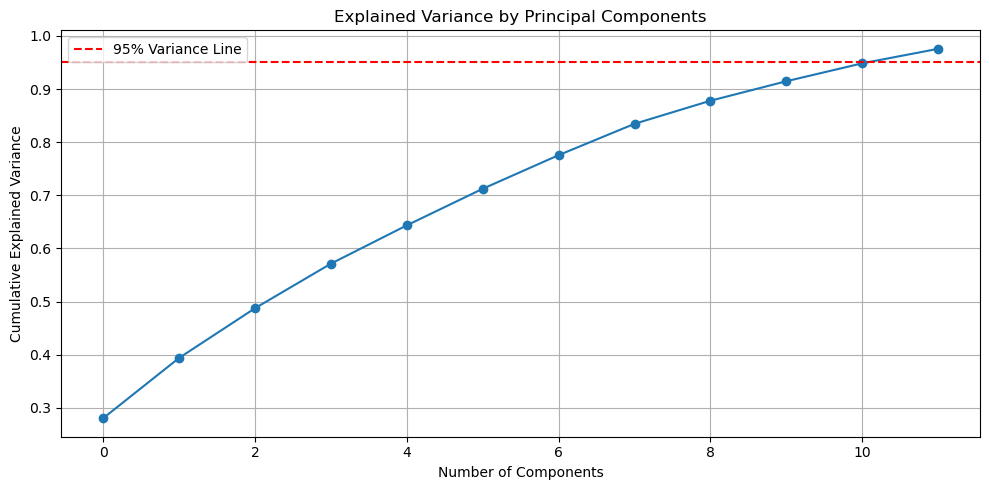

Original shape: (303, 13)
Reduced shape after PCA: (303, 12)


In [11]:
X = df.drop(columns='num')                             # Removing target column if present

pca = PCA(n_components=0.95)                            ## 95 % variance 
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Principal Components')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Line')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Original shape: {X_scaled.shape}")
print(f"Reduced shape after PCA: {X_pca.shape}")

## Grouping Patients based on Health Profiles(K Means Clustering)

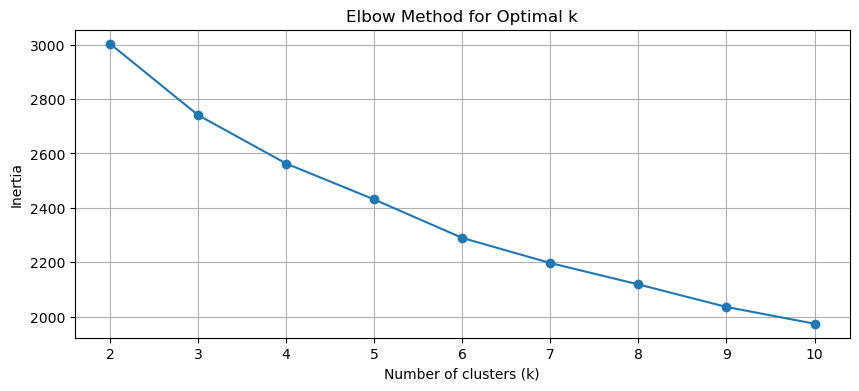

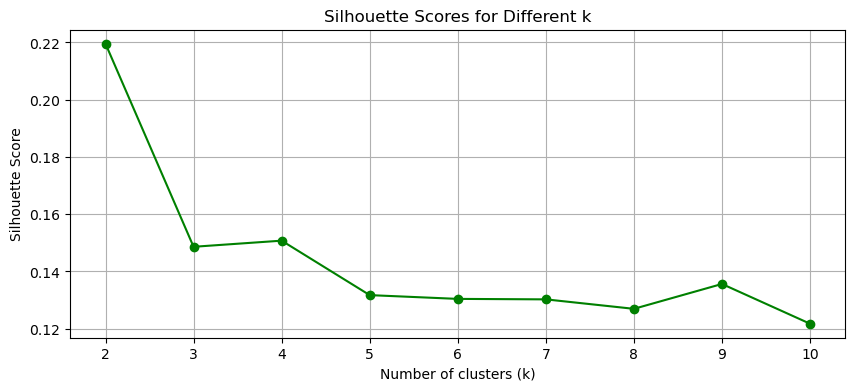

Optimal number of clusters (k): 2


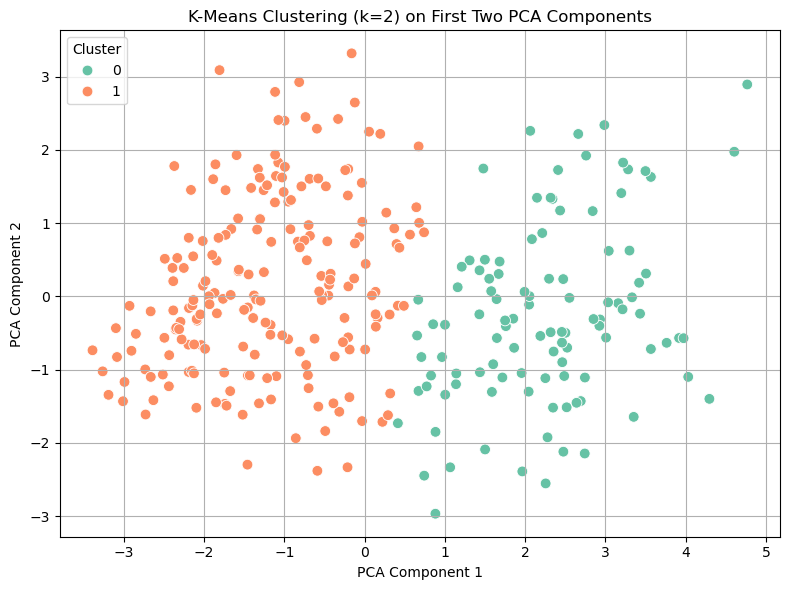

In [12]:
inertia = []                             # Elbow Method and Silhouette Score
sil_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=5, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_pca, kmeans.labels_))

 
plt.figure(figsize=(10, 4))                    ## Plotting elbow method 
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 4))                     ## Plotting Silhouette Score
plt.plot(K, sil_scores, marker='o', color='green')
plt.title("Silhouette Scores for Different k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

## Applying KMeans with the best k
optimal_k = sil_scores.index(max(sil_scores)) + 2   ## since K starts from 2
print(f"Optimal number of clusters (k): {optimal_k}")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=5, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca)


plt.figure(figsize=(8, 6))                          ## clusters using first two PCA components
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],hue=cluster_labels,palette='Set2',s=60)
plt.title(f"K-Means Clustering (k={optimal_k}) on First Two PCA Components")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()